In [7]:
!pip install mtcnn

In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from mtcnn import MTCNNs


class FaceExtractorMTCNN:

    def __init__(self, target_size=(256, 256)):
        self.detector = MTCNN()
        self.target_size = target_size

    def extract_face(self, image_path):
        try:
            img = cv2.imread(image_path)

            if img is None:
                return None

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h_img, w_img, _ = img.shape

            results = self.detector.detect_faces(img_rgb)

            if len(results) == 0:
                return None

            # ✅ Take largest detected face
            face = max(results, key=lambda x: x['box'][2] * x['box'][3])
            x, y, w, h = face['box']

            # ✅ Fix negative values
            x = max(0, x)
            y = max(0, y)

            # ✅ Fix overflow beyond image size
            x2 = min(w_img, x + w)
            y2 = min(h_img, y + h)

            face_crop = img_rgb[y:y2, x:x2]

            if face_crop.size == 0:
                return None

            # ✅ Resize
            face_resized = cv2.resize(face_crop, self.target_size)

            # ✅ Normalize
            face_normalized = face_resized.astype(np.float32) / 255.0

            return face_normalized

        except Exception as e:
            print(f"Error: {image_path} -> {e}")
            return None

    def preprocess_dataset(self, input_dir, output_dir, split):

        classes = ['real', 'fake']

        stats = {
            cls: {'total': 0, 'extracted': 0, 'failed': 0}
            for cls in classes
        }

        for cls in classes:

            input_class_dir = os.path.join(input_dir, split, cls)
            output_class_dir = os.path.join(output_dir, split, cls)

            os.makedirs(output_class_dir, exist_ok=True)

            if not os.path.exists(input_class_dir):
                print(f"Missing: {input_class_dir}")
                continue

            images = [
                f for f in os.listdir(input_class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            stats[cls]['total'] = len(images)

            print(f"\nProcessing {split}/{cls}: {len(images)} images")

            for img_file in tqdm(images):

                in_path = os.path.join(input_class_dir, img_file)
                out_path = os.path.join(output_class_dir, img_file)

                face = self.extract_face(in_path)

                if face is not None:
                    face_uint8 = (face * 255).astype(np.uint8)
                    cv2.imwrite(out_path, cv2.cvtColor(face_uint8, cv2.COLOR_RGB2BGR))
                    stats[cls]['extracted'] += 1
                else:
                    stats[cls]['failed'] += 1

        # ✅ Summary
        print("\n" + "=" * 50)
        print(f"{split.upper()} SUMMARY")
        print("=" * 50)

        for cls in classes:
            total = stats[cls]['total']
            extracted = stats[cls]['extracted']
            failed = stats[cls]['failed']

            print(f"{cls}: {extracted}/{total} extracted | Failed: {failed}")

        return stats


def main():

    # ✅ Kaggle dataset path
    raw_data_dir = "/kaggle/input/datasets/vasubhut/deep-fake-face-detection/Data Set 1/Data Set 1"

    # ✅ Output directory
    processed_data_dir = "/kaggle/working/processed_faces_mtcnn"

    extractor = FaceExtractorMTCNN(target_size=(256, 256))

    splits = ["train", "validation", "test"]

    for split in splits:
        print(f"\n{'=' * 60}")
        print(f"Processing {split}")
        print(f"{'=' * 60}")

        extractor.preprocess_dataset(
            input_dir=raw_data_dir,
            output_dir=processed_data_dir,
            split=split
        )

    print("\n✅ DONE")
    print(f"Saved at: {processed_data_dir}")


if __name__ == "__main__":
    main()


Processing train

Processing train/real: 20001 images


100%|██████████| 20001/20001 [51:23<00:00,  6.49it/s]



Processing train/fake: 20001 images


100%|██████████| 20001/20001 [51:17<00:00,  6.50it/s]



TRAIN SUMMARY
real: 19785/20001 extracted | Failed: 216
fake: 19681/20001 extracted | Failed: 320

Processing validation

Processing validation/real: 6199 images


...


VALIDATION SUMMARY
real: 6144/6199 extracted | Failed: 55
fake: 6141/6161 extracted | Failed: 20

Processing test

Processing test/real: 2604 images


100%|██████████| 2604/2604 [07:05<00:00,  6.11it/s]



Processing test/fake: 2623 images


100%|██████████| 2623/2623 [07:03<00:00,  6.20it/s]


TEST SUMMARY
real: 2163/2604 extracted | Failed: 441
fake: 2475/2623 extracted | Failed: 148

✅ DONE
Saved at: /kaggle/working/processed_faces_mtcnn


In [ ]:
!zip -r mtcnn_processed.zip /kaggle/working/processed_faces_mtcnn

In [ ]:
from IPython.display import FileLink
FileLink('mtcnn_output_final.zip')

In [4]:
#Best-High-Performing-Training-Code
import os, json, math, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
EPOCHS         = 20
PEAK_LR        = 1e-4
WARMUP_EPOCHS  = 10
MIN_LR         = 1e-6
WEIGHT_DECAY   = 0.05
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1

MODEL_PATH  = "/kaggle/working/cswin_best.keras"
EPOCH_FILE  = "/kaggle/working/last_epoch.json"
DATA_DIR    = "/kaggle/input/datasets/sahanakarthikeyan/mtcnn-output/mtcnn_output"


# ══════════════════════════════════════════════════════════════════════════════
# LR SCHEDULE
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr      = float(peak_lr)
        self.min_lr       = float(min_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step    = tf.cast(step, tf.float32)
        warmup  = self.peak_lr * (step / tf.maximum(self.warmup_steps, 1.0))
        cos_arg = math.pi * (step - self.warmup_steps) / \
                  tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        cosine  = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * \
                  (1.0 + tf.cos(cos_arg))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {"peak_lr": self.peak_lr, "min_lr": self.min_lr,
                "warmup_steps": self.warmup_steps, "total_steps": self.total_steps}


# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════

def _get_class_names(data_dir):
    train_path = os.path.join(data_dir, "train")
    folders = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
    fake_folder = next((f for f in folders if "fake" in f.lower()), folders[0])
    real_folder = next((f for f in folders if "real" in f.lower()), folders[-1])
    print(f"[LABELS]  0='{fake_folder}' (FAKE)   1='{real_folder}' (REAL)")
    return [fake_folder, real_folder]


def create_datasets():
    class_names = _get_class_names(DATA_DIR)

    def _load(split, augment=False):
        ds = keras.preprocessing.image_dataset_from_directory(
            os.path.join(DATA_DIR, split),
            image_size=IMG_SIZE, batch_size=BATCH_SIZE,
            label_mode="binary", class_names=class_names,
            shuffle=(split == "train"), seed=42,
        )
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        if augment:
            ds = ds.map(
                lambda x, y: (tf.image.random_flip_left_right(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = _load("train",      augment=True)
    val_ds   = _load("validation", augment=False)
    test_ds  = _load("test",       augment=False)

    class_weight = None
    try:
        train_path = os.path.join(DATA_DIR, "train")
        counts = {cls: len([f for f in os.listdir(os.path.join(train_path, cls))
                             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
                  for cls in class_names}
        n0, n1 = counts[class_names[0]], counts[class_names[1]]
        total  = n0 + n1
        ratio  = max(n0, n1) / (min(n0, n1) + 1e-6)
        print(f"[DATA]  FAKE:{n0}  REAL:{n1}  ratio:{ratio:.2f}")
        if ratio > 1.2:
            class_weight = {0: total/(2*n0), 1: total/(2*n1)}
            print(f"[DATA]  class_weight={class_weight}")
    except Exception as e:
        print(f"[DATA]  class weight error: {e}")

    return train_ds, val_ds, test_ds, class_weight, class_names


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════

class DropPath(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = float(drop_prob)

    def call(self, x, training=False):
        if not training or self.drop_prob == 0.0:
            return x
        keep  = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        noise = keep + tf.random.uniform(shape, dtype=x.dtype)
        return x * tf.math.floor(noise) / keep

    def get_config(self):
        cfg = super().get_config()
        cfg["drop_prob"] = self.drop_prob
        return cfg


class PatchEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.proj      = layers.Conv2D(dim, kernel_size=4, strides=4,
                                       padding="same", name="patch_proj")
        self.norm      = layers.LayerNormalization(epsilon=1e-5, name="patch_norm")
        # pos_embed allocated in build(); initialised to None here so
        # get_config / from_config works before build() is called.
        self._pe_shape = None

    def build(self, input_shape):
        H = int(input_shape[1])
        W = int(input_shape[2])
        pH, pW = H // 4, W // 4
        self._pe_shape = (1, pH, pW, self.dim)
        # Use explicit keyword arguments only — avoids the positional/keyword
        # conflict that appears in Keras 3.x when shape is passed positionally.
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=self._pe_shape,
            initializer="zeros",
            trainable=True,
            dtype=tf.float32,
        )
        super().build(input_shape)

    def call(self, x):
        x = self.proj(x)
        x = x + tf.cast(self.pos_embed, x.dtype)
        return self.norm(x)

    def get_config(self):
        cfg = super().get_config()
        cfg["dim"] = self.dim
        return cfg


# ── Stripe helpers ────────────────────────────────────────────────────────────

def h_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H // s, s, W, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B * (H // s), W * s, C])

def h_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, H // s, W, s, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B, H, W, C])

def v_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H, W // s, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B * (W // s), H * s, C])

def v_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, W // s, H, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B, H, W, C])


class StripeAttention(layers.Layer):
    def __init__(self, dim, num_heads, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv  = layers.Dense(dim * 3, use_bias=True, name="qkv")
        self.proj = layers.Dense(dim,      use_bias=True, name="proj")
        self.drop = layers.Dropout(attn_drop)

    def call(self, x, training=False):
        B = tf.shape(x)[0]; N = tf.shape(x)[1]; C = x.shape[-1]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.drop(attn, training=training)
        out  = tf.matmul(attn, v)
        out  = tf.transpose(out, [0, 2, 1, 3])
        out  = tf.reshape(out, [B, N, C])
        return self.proj(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.num_heads * self.head_dim,
                    "num_heads": self.num_heads})
        return cfg


class CSWinAttention(layers.Layer):
    def __init__(self, dim, num_heads, split_size, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        assert dim % 2 == 0
        self.split_size = split_size
        self.dim_half   = dim // 2
        hh = max(1, num_heads // 2)
        self.attn_h = StripeAttention(self.dim_half, hh, attn_drop, name="attn_h")
        self.attn_v = StripeAttention(self.dim_half, hh, attn_drop, name="attn_v")
        self.lepe_h = layers.DepthwiseConv2D(3, padding="same", name="lepe_h")
        self.lepe_v = layers.DepthwiseConv2D(3, padding="same", name="lepe_v")

    def call(self, x, training=False):
        B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]
        s  = self.split_size
        x1, x2 = tf.split(x, 2, axis=-1)
        x_h = h_merge(self.attn_h(h_split(x1, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_h(x1)
        x_v = v_merge(self.attn_v(v_split(x2, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_v(x2)
        return tf.concat([x_h, x_v], axis=-1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim_half * 2,
                    "num_heads": self.attn_h.num_heads * 2,
                    "split_size": self.split_size})
        return cfg


class CSWinBlock(layers.Layer):
    def __init__(self, dim, num_heads, split_size, mlp_ratio=4.0,
                 drop_path=0.0, proj_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-5, name="norm1")
        self.attn  = CSWinAttention(dim, num_heads, split_size, name="attn")
        self.dp1   = DropPath(drop_path, name="dp1")
        self.norm2 = layers.LayerNormalization(epsilon=1e-5, name="norm2")
        self.mlp   = keras.Sequential([
            layers.Dense(int(dim * mlp_ratio), activation="gelu", name="fc1"),
            layers.Dropout(proj_drop),
            layers.Dense(dim, name="fc2"),
            layers.Dropout(proj_drop),
        ], name="mlp")
        self.dp2 = DropPath(drop_path, name="dp2")

    def call(self, x, training=False):
        x = x + self.dp1(self.attn(self.norm1(x), training=training),
                         training=training)
        x = x + self.dp2(self.mlp(self.norm2(x),  training=training),
                         training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim":        self.attn.dim_half * 2,
                    "num_heads":  self.attn.attn_h.num_heads * 2,
                    "split_size": self.attn.split_size})
        return cfg


class PatchMerging(layers.Layer):
    def __init__(self, out_dim, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.conv = layers.Conv2D(out_dim, kernel_size=2, strides=2,
                                   padding="same", name="down_conv")
        self.norm = layers.LayerNormalization(epsilon=1e-5, name="down_norm")

    def call(self, x):
        return self.norm(self.conv(x))

    def get_config(self):
        cfg = super().get_config()
        cfg["out_dim"] = self.out_dim
        return cfg


class CSWinTransformer(keras.Model):
    def __init__(self,
                 embed_dim=64,
                 depths=(2, 2, 6, 2),
                 num_heads=(2, 4, 8, 16),
                 split_sizes=(2, 2, 4, 2),
                 mlp_ratio=4.0,
                 drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,
                 num_classes=1,
                 **kwargs):
        super().__init__(**kwargs)

        dpr     = list(np.linspace(0, drop_path_rate, sum(depths)))
        blk_idx = 0
        dim     = embed_dim

        self.patch_embed    = PatchEmbedding(embed_dim, name="patch_embed")
        self._stage_configs = []

        for si, (depth, heads, split) in enumerate(
                zip(depths, num_heads, split_sizes)):
            names = []
            for b in range(depth):
                n   = f"s{si}_b{b}"
                blk = CSWinBlock(dim, heads, split, mlp_ratio,
                                 dpr[blk_idx], proj_drop, name=n)
                setattr(self, n, blk)
                names.append(n)
                blk_idx += 1
            dn = None
            if si < len(depths) - 1:
                dn = f"down_{si}"
                setattr(self, dn, PatchMerging(dim * 2, name=dn))
                dim *= 2
            self._stage_configs.append((names, dn))

        self.final_norm = layers.LayerNormalization(epsilon=1e-5, name="final_norm")
        self.gap        = layers.GlobalAveragePooling2D(name="gap")
        self.head_drop  = layers.Dropout(proj_drop, name="head_drop")
        self.head       = layers.Dense(num_classes, activation="sigmoid",
                                       name="head", dtype="float32")

    def call(self, x, training=False):
        x = self.patch_embed(x)
        for names, dn in self._stage_configs:
            for n in names:
                x = getattr(self, n)(x, training=training)
            if dn is not None:
                x = getattr(self, dn)(x)
        x = self.final_norm(x)
        x = self.gap(x)
        x = self.head_drop(x, training=training)
        return self.head(x)

    def get_config(self):
        return {
            "embed_dim":      64,
            "depths":         [2, 2, 6, 2],
            "num_heads":      [2, 4, 8, 16],
            "split_sizes":    [2, 2, 4, 2],
            "mlp_ratio":      4.0,
            "drop_path_rate": DROP_PATH_RATE,
            "proj_drop":      DROPOUT,
            "num_classes":    1,
        }


CUSTOM_OBJECTS = {
    "CSWinTransformer":  CSWinTransformer,
    "CSWinBlock":        CSWinBlock,
    "CSWinAttention":    CSWinAttention,
    "StripeAttention":   StripeAttention,
    "PatchEmbedding":    PatchEmbedding,
    "PatchMerging":      PatchMerging,
    "DropPath":          DropPath,
    "WarmupCosineDecay": WarmupCosineDecay,
}


# ══════════════════════════════════════════════════════════════════════════════
# BUILD
# ══════════════════════════════════════════════════════════════════════════════

def build_model(steps_per_epoch):
    model = CSWinTransformer()
    model(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)

    total  = steps_per_epoch * EPOCHS
    warmup = steps_per_epoch * WARMUP_EPOCHS
    sched  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup, total)
    opt    = keras.optimizers.AdamW(
        learning_rate=sched,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    )
    model.compile(
        optimizer=opt,
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    model.summary()
    return model


# ══════════════════════════════════════════════════════════════════════════════
# OVERFIT PROBE
# ══════════════════════════════════════════════════════════════════════════════

def overfit_probe(train_ds, n=128, epochs=60):
    print("\n" + "=" * 60)
    print("  OVERFIT PROBE — must reach >= 0.95 accuracy")
    print("=" * 60)
    imgs, lbls = [], []
    for x, y in train_ds:
        imgs.append(x.numpy()); lbls.append(y.numpy())
        if sum(len(a) for a in imgs) >= n:
            break
    imgs = np.concatenate(imgs)[:n]
    lbls = np.concatenate(lbls)[:n]
    print(f"  Subset  FAKE:{int((lbls==0).sum())}  REAL:{int((lbls==1).sum())}")

    m = CSWinTransformer()
    m(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)
    m.compile(
        optimizer=keras.optimizers.AdamW(1e-4, weight_decay=0.0, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    h   = m.fit(imgs, lbls, epochs=epochs, batch_size=16, verbose=0)
    acc = h.history["accuracy"][-1]
    print(f"  Final accuracy: {acc:.4f}")
    if acc >= 0.95:
        print("  PASS  architecture healthy.")
    elif acc >= 0.70:
        print("  PARTIAL  may still train; check data pipeline.")
    else:
        print("  FAIL  architecture broken; do not proceed.")
    return acc


# ══════════════════════════════════════════════════════════════════════════════
# CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════

class EpochLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(EPOCH_FILE, "w") as f:
            json.dump({"epoch": epoch + 1}, f)


def build_callbacks():
    # NOTE: ReduceLROnPlateau is intentionally omitted.
    # The optimizer uses a WarmupCosineDecay LearningRateSchedule, and
    # Keras 3.x raises TypeError if you try to set .learning_rate on such
    # an optimizer at runtime. The cosine schedule handles LR decay automatically.
    return [
        keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor="val_auc", mode="max",
            save_best_only=True, verbose=1,
        ),
        EpochLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=20, restore_best_weights=True, verbose=1,
        ),
    ]


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("\n" + "=" * 70)
    print("  CSWin Transformer  Research-Grade Training")
    print("=" * 70)

    train_ds, val_ds, test_ds, class_weight, class_names = create_datasets()
    steps = sum(1 for _ in train_ds)
    print(f"\n  Steps/epoch={steps}  Total={steps*EPOCHS}"
          f"  Warmup={steps*WARMUP_EPOCHS}")

    # ── Checkpoint resume logic ───────────────────────────────────────────────
    # Priority 1: working directory checkpoint (most recent)
    # Priority 2: input dataset backup checkpoint
    # Priority 3: start from scratch
    initial_epoch = 0

    def _try_load(path):
        with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
            m = keras.models.load_model(path, compile=False)
        total  = steps * EPOCHS
        warmup = steps * WARMUP_EPOCHS
        sched  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup, total)
        opt    = keras.optimizers.AdamW(
            learning_rate=sched, weight_decay=WEIGHT_DECAY, clipnorm=1.0)
        m.compile(
            optimizer=opt,
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            metrics=["accuracy",
                     keras.metrics.AUC(name="auc"),
                     keras.metrics.Precision(name="precision"),
                     keras.metrics.Recall(name="recall")],
        )
        return m

    BACKUP_CKPT = "/kaggle/input/datasets/sahanakarthikeyan/cswin-checkpoints/cswin_best.keras"

    if os.path.exists(MODEL_PATH):
        print(f"  Resuming from working checkpoint: {MODEL_PATH}")
        model = _try_load(MODEL_PATH)
    elif os.path.exists(BACKUP_CKPT):
        print(f"  Restoring from input backup: {BACKUP_CKPT}")
        shutil.copy(BACKUP_CKPT, MODEL_PATH)
        backup_epoch = BACKUP_CKPT.replace("cswin_best.keras", "last_epoch.json")
        if os.path.exists(backup_epoch):
            shutil.copy(backup_epoch, EPOCH_FILE)
        model = _try_load(MODEL_PATH)
    else:
        print("  No checkpoint found — starting from scratch")
        model = build_model(steps)

    if os.path.exists(EPOCH_FILE):
        with open(EPOCH_FILE) as f:
            initial_epoch = json.load(f).get("epoch", 0)
        print(f"  Resuming from epoch {initial_epoch + 1}")

    # Uncomment to verify before full run:
    # probe_acc = overfit_probe(train_ds)
    # if probe_acc < 0.70:
    #     raise RuntimeError("Architecture failed overfit probe")

    print(f"\n  Training from epoch {initial_epoch + 1} ...\n")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        callbacks=build_callbacks(),
        class_weight=class_weight,
    )

    print("\n" + "=" * 60)
    print("  TEST SET EVALUATION")
    print("=" * 60)
    results = model.evaluate(test_ds, return_dict=True)
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")


if __name__ == "__main__":
    main()


  CSWin Transformer  Research-Grade Training
[LABELS]  0='fake' (FAKE)   1='real' (REAL)
Found 28981 files belonging to 2 classes.
Found 9175 files belonging to 2 classes.
Found 3580 files belonging to 2 classes.
[DATA]  FAKE:13328  REAL:15653  ratio:1.17

  Steps/epoch=906  Total=18120  Warmup=9060
  Resuming from working checkpoint: /kaggle/working/cswin_best.keras
  Resuming from epoch 11

  Training from epoch 11 ...

Epoch 11/20
906/906 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8949 - auc: 0.9585 - loss: 0.3209 - precision: 0.9075 - recall: 0.8973
Epoch 11: val_auc improved from -inf to 0.90238, saving model to /kaggle/working/cswin_best.keras
906/906 ━━━━━━━━━━━━━━━━━━━━ 392s 275ms/step - accuracy: 0.8949 - auc: 0.9585 - loss: 0.3209 - precision: 0.9075 - recall: 0.8973 - val_accuracy: 0.8544 - val_auc: 0.9024 - val_loss: 0.4580 - val_precision: 0.8421 - val_recall: 0.8890
Epoch 12/20
906/906 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9003 - auc: 0.9639 - loss: 0.30

CSWin Transformer  Evaluation
[LABELS]  0='fake' (FAKE)   1='real' (REAL)
Found 3580 files belonging to 2 classes.

112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step

  ROC-AUC  : 0.7231
  Avg Prec : 0.5930
  Optimal threshold (Youden-J): 0.3474
              precision    recall  f1-score   support

        FAKE     0.8027    0.5846    0.6765      1914
        REAL     0.6363    0.8349    0.7222      1666

    accuracy                         0.7011      3580
   macro avg     0.7195    0.7098    0.6994      3580
weighted avg     0.7253    0.7011    0.6978      3580


Plots saved to /kaggle/working/eval_plots/cswin_evaluation.png


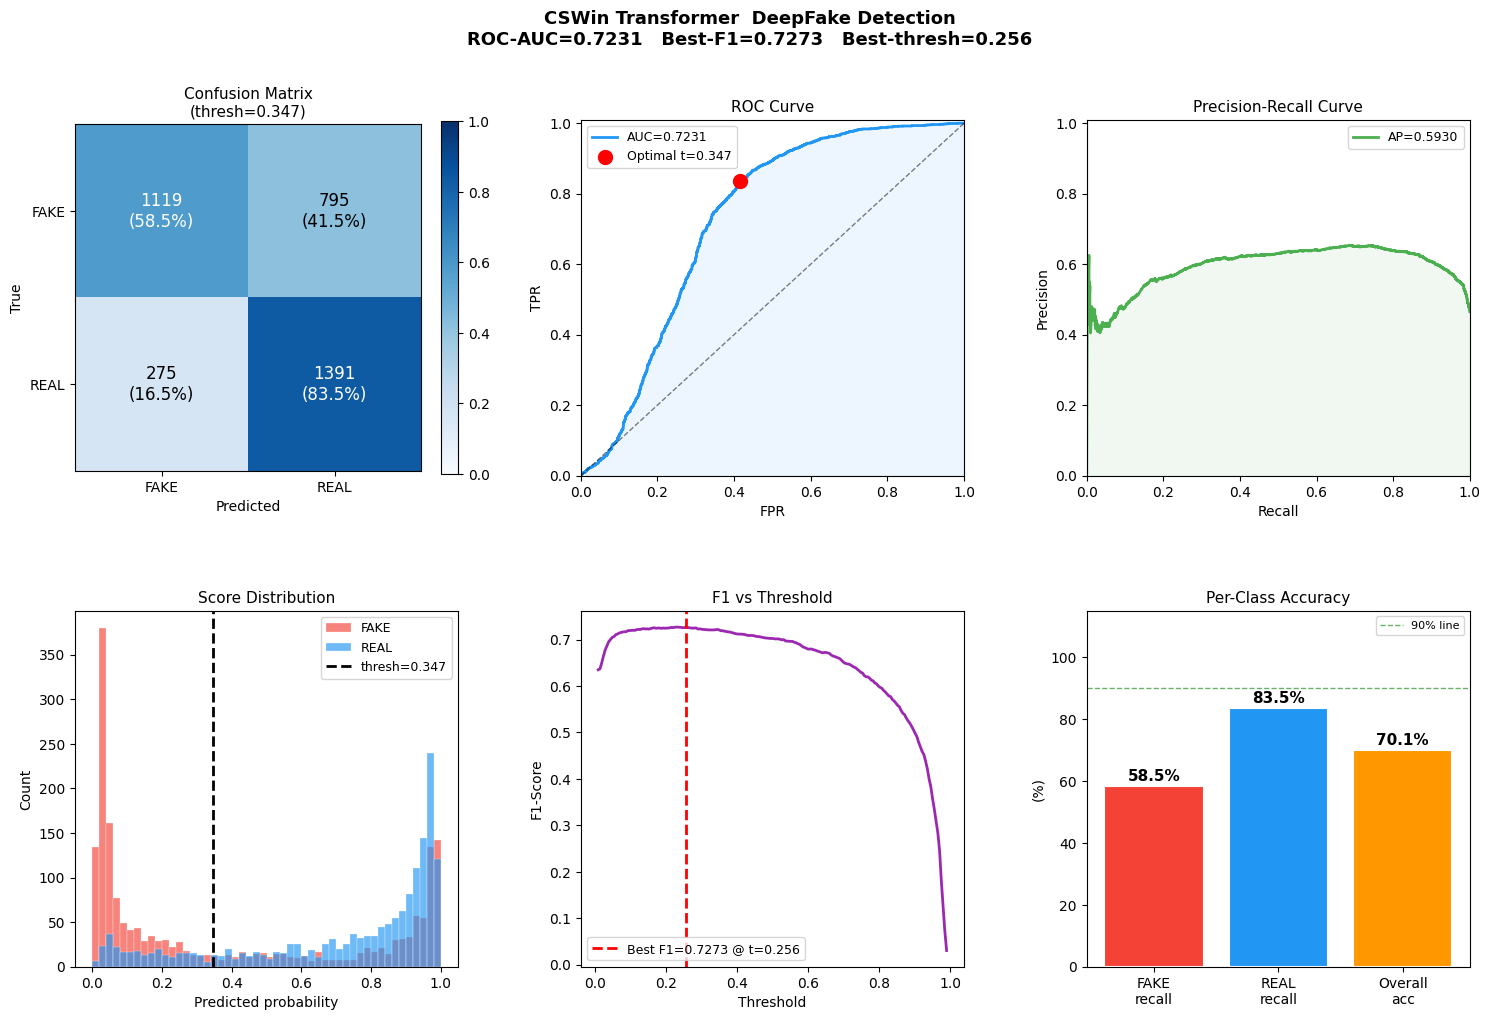


  SUMMARY
  ROC-AUC        : 0.7231
  Average Prec   : 0.5930
  Best F1-Score  : 0.7273  @ threshold 0.256
  FAKE recall    : 58.46%
  REAL recall    : 83.49%
  Overall acc    : 70.11%
  TN=1119  FP=795  FN=275  TP=1391


In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, f1_score,
)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — must match training
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1
MODEL_PATH     = "/kaggle/input/datasets/sahanakarthikeyan/cswin-checkpoints/cswin_best.keras"
DATA_DIR       = "/kaggle/input/datasets/sahanakarthikeyan/mtcnn-output/mtcnn_output"
OUT_DIR        = "/kaggle/working/eval_plots"
os.makedirs(OUT_DIR, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE — identical to training file
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr); self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps); self.total_steps=float(total_steps)
    def __call__(self, step):
        import math
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}


class DropPath(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs); self.drop_prob=float(drop_prob)
    def call(self, x, training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config(); cfg["drop_prob"]=self.drop_prob; return cfg


class PatchEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
        self._pe_shape=None
    def build(self, input_shape):
        H=int(input_shape[1]); W=int(input_shape[2])
        self._pe_shape=(1,H//4,W//4,self.dim)
        self.pos_embed=self.add_weight(
            name="pos_embed", shape=self._pe_shape,
            initializer="zeros", trainable=True, dtype=tf.float32)
        super().build(input_shape)
    def call(self, x):
        return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config(); cfg["dim"]=self.dim; return cfg


def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])


class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg


class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0
        self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg


class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
                                    layers.Dropout(proj_drop),layers.Dense(dim,name="fc2"),
                                    layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg


class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg


class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed")
        self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}"; setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n)); ns.append(n); bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}"; setattr(self,dn,PatchMerging(dim*2,name=dn)); dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}


CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}


# ══════════════════════════════════════════════════════════════════════════════
# DATA + MODEL LOADING
# ══════════════════════════════════════════════════════════════════════════════

def get_class_names():
    train_path = os.path.join(DATA_DIR, "train")
    folders = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
    fake = next((f for f in folders if "fake" in f.lower()), folders[0])
    real = next((f for f in folders if "real" in f.lower()), folders[-1])
    print(f"[LABELS]  0='{fake}' (FAKE)   1='{real}' (REAL)")
    return [fake, real]

def load_test_ds(class_names):
    ds = keras.preprocessing.image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        label_mode="binary", class_names=class_names, shuffle=False)
    return ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y)).prefetch(tf.data.AUTOTUNE)

def load_model():
    with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
        m = keras.models.load_model(MODEL_PATH, compile=False)
    m.compile(loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION + PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_and_plot(model, test_ds):
    print("\nCollecting predictions ...")
    y_prob = model.predict(test_ds, verbose=1).flatten()
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten()

    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    fpr, tpr, thresh_roc = roc_curve(y_true, y_prob)
    prec, rec, _         = precision_recall_curve(y_true, y_prob)

    # Optimal threshold via Youden-J
    best_i = int(np.argmax(tpr - fpr))
    best_t = float(thresh_roc[best_i])
    y_pred = (y_prob >= best_t).astype(int)

    print(f"\n{'='*60}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Avg Prec : {ap:.4f}")
    print(f"  Optimal threshold (Youden-J): {best_t:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                 target_names=["FAKE", "REAL"], digits=4))

    # F1 vs threshold sweep
    t_range = np.linspace(0.01, 0.99, 200)
    f1s     = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
               for t in t_range]
    best_f1_t = t_range[int(np.argmax(f1s))]

    # Confusion matrix
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    tn, fp, fn, tp = cm.ravel()

    # ── 6-panel figure ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    # Panel 1 — Confusion matrix
    ax1 = fig.add_subplot(gs[0, 0])
    im  = ax1.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax1.text(j, i,
                     f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                     ha="center", va="center", fontsize=12,
                     color="white" if cm_norm[i,j] > 0.5 else "black")
    ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
    ax1.set_xticklabels(["FAKE", "REAL"])
    ax1.set_yticklabels(["FAKE", "REAL"])
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
    ax1.set_title(f"Confusion Matrix\n(thresh={best_t:.3f})", fontsize=11)
    plt.colorbar(im, ax=ax1, fraction=0.046)

    # Panel 2 — ROC curve
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(fpr, tpr, lw=2, color="#2196F3", label=f"AUC={auc:.4f}")
    ax2.scatter(fpr[best_i], tpr[best_i], s=100, color="red", zorder=5,
                label=f"Optimal t={best_t:.3f}")
    ax2.fill_between(fpr, tpr, alpha=0.08, color="#2196F3")
    ax2.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
    ax2.set_title("ROC Curve", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.01])

    # Panel 3 — Precision-Recall
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(rec, prec, lw=2, color="#4CAF50", label=f"AP={ap:.4f}")
    ax3.fill_between(rec, prec, alpha=0.08, color="#4CAF50")
    ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
    ax3.set_title("Precision-Recall Curve", fontsize=11)
    ax3.legend(fontsize=9)
    ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.01])

    # Panel 4 — Score distribution
    ax4 = fig.add_subplot(gs[1, 0])
    bins = np.linspace(0, 1, 51)
    ax4.hist(y_prob[y_true==0], bins=bins, alpha=0.65,
             color="#F44336", label="FAKE", edgecolor="white", linewidth=0.3)
    ax4.hist(y_prob[y_true==1], bins=bins, alpha=0.65,
             color="#2196F3", label="REAL", edgecolor="white", linewidth=0.3)
    ax4.axvline(best_t, color="black", lw=2, linestyle="--",
                label=f"thresh={best_t:.3f}")
    ax4.set_xlabel("Predicted probability"); ax4.set_ylabel("Count")
    ax4.set_title("Score Distribution", fontsize=11)
    ax4.legend(fontsize=9)

    # Panel 5 — F1 vs threshold
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(t_range, f1s, lw=2, color="#9C27B0")
    ax5.axvline(best_f1_t, color="red", lw=2, linestyle="--",
                label=f"Best F1={max(f1s):.4f} @ t={best_f1_t:.3f}")
    ax5.set_xlabel("Threshold"); ax5.set_ylabel("F1-Score")
    ax5.set_title("F1 vs Threshold", fontsize=11)
    ax5.legend(fontsize=9)

    # Panel 6 — Per-class recall bar
    ax6 = fig.add_subplot(gs[1, 2])
    fake_acc = tn / (tn + fp) * 100
    real_acc = tp / (tp + fn) * 100
    overall  = (tn + tp) / cm.sum() * 100
    bars = ax6.bar(["FAKE\nrecall", "REAL\nrecall", "Overall\nacc"],
                   [fake_acc, real_acc, overall],
                   color=["#F44336", "#2196F3", "#FF9800"],
                   edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, [fake_acc, real_acc, overall]):
        ax6.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=11, fontweight="bold")
    ax6.set_ylim([0, 115]); ax6.set_ylabel("(%)")
    ax6.set_title("Per-Class Accuracy", fontsize=11)
    ax6.axhline(90, color="green", linestyle="--", lw=1,
                alpha=0.6, label="90% line")
    ax6.legend(fontsize=8)

    fig.suptitle(
        f"CSWin Transformer  DeepFake Detection\n"
        f"ROC-AUC={auc:.4f}   Best-F1={max(f1s):.4f}   "
        f"Best-thresh={best_f1_t:.3f}",
        fontsize=13, fontweight="bold", y=0.98)

    out = os.path.join(OUT_DIR, "cswin_evaluation.png")
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\nPlots saved to {out}")
    plt.show()

    print(f"\n{'='*60}")
    print(f"  SUMMARY")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Average Prec   : {ap:.4f}")
    print(f"  Best F1-Score  : {max(f1s):.4f}  @ threshold {best_f1_t:.3f}")
    print(f"  FAKE recall    : {fake_acc:.2f}%")
    print(f"  REAL recall    : {real_acc:.2f}%")
    print(f"  Overall acc    : {overall:.2f}%")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"{'='*60}")


def main():
    print("CSWin Transformer  Evaluation")
    class_names = get_class_names()
    test_ds     = load_test_ds(class_names)
    model       = load_model()
    evaluate_and_plot(model, test_ds)


if __name__ == "__main__":
    main()

In [5]:
"""
DeepFake Predictor + SHAP Explainability
=========================================
Paste this entire cell in Kaggle and run it.

Explainability methods used:
  1. GradCAM (input-gradient)   — works on ANY model including subclassed
  2. SHAP GradientExplainer     — most compatible with subclassed Keras models
  3. Occlusion sensitivity      — model-agnostic, no architecture assumptions
  4. Region importance bars     — human-interpretable anatomical breakdown

Why GradientExplainer over DeepExplainer:
  DeepExplainer requires model.inputs (Functional API only).
  GradientExplainer uses tf.GradientTape internally and works on
  any callable TF model, including subclassed models like CSWinTransformer.
"""

# ── Installs ──────────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["ipywidgets", "shap"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

import os, math, urllib.request, warnings
warnings.filterwarnings("ignore")

from IPython.display import display
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from scipy.ndimage import gaussian_filter
from IPython.display import display, clear_output
import ipywidgets as widgets

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
MODEL_PATH     = "/kaggle/input/datasets/sahanakarthikeyan/cswin-checkpoints/cswin_best.keras"
IMG_SIZE       = (128, 128)
THRESHOLD      = 0.5
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1
OUT_DIR        = "/kaggle/working"

# SHAP / explainability settings
SHAP_N_BG       = 30    # background samples for GradientExplainer
SHAP_N_GRAD     = 10    # gradient samples per background (SmoothGrad-style)
OCC_PATCH_SIZE  = 8     # occlusion patch size in pixels

# ══════════════════════════════════════════════════════════════════════════════
# FACE DETECTOR  — OpenCV DNN, Python 3.12 compatible
# ══════════════════════════════════════════════════════════════════════════════
_DNN_PROTO = "/tmp/deploy.prototxt"
_DNN_MODEL = "/tmp/res10_300x300_ssd_iter_140000.caffemodel"
_PROTO_URL = ("https://raw.githubusercontent.com/opencv/opencv/master/"
              "samples/dnn/face_detector/deploy.prototxt")
_MODEL_URL = ("https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_"
              "face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel")

def _download_dnn_files():
    ok = True
    for path, url in [(_DNN_PROTO, _PROTO_URL), (_DNN_MODEL, _MODEL_URL)]:
        if not os.path.exists(path):
            try:
                print(f"  Downloading {os.path.basename(path)} ...")
                urllib.request.urlretrieve(url, path)
            except Exception as e:
                print(f"  Download failed: {e}"); ok = False
    return ok

class FaceDetectorCV:
    def __init__(self):
        self._dnn_net = None; self._haar = None
        self._init_dnn(); self._init_haar()

    def _init_dnn(self):
        if _download_dnn_files():
            try:
                self._dnn_net = cv2.dnn.readNetFromCaffe(_DNN_PROTO, _DNN_MODEL)
                print("  OpenCV DNN face detector loaded.")
            except Exception as e:
                print(f"  DNN load failed ({e}), using Haar fallback.")

    def _init_haar(self):
        p = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self._haar = cv2.CascadeClassifier(p)
        if self._haar.empty(): self._haar = None

    def detect(self, img_rgb):
        faces = []
        if self._dnn_net is not None:
            h, w = img_rgb.shape[:2]
            blob = cv2.dnn.blobFromImage(
                cv2.resize(img_rgb, (300, 300)), 1.0,
                (300, 300), (104.0, 177.0, 123.0))
            self._dnn_net.setInput(blob)
            dets = self._dnn_net.forward()
            for i in range(dets.shape[2]):
                c = float(dets[0, 0, i, 2])
                if c < 0.5: continue
                box = dets[0, 0, i, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)
                x1=max(0,x1); y1=max(0,y1); x2=min(w,x2); y2=min(h,y2)
                fw, fh = x2-x1, y2-y1
                if fw > 0 and fh > 0:
                    faces.append((x1, y1, fw, fh, c))
        if not faces and self._haar is not None:
            gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            rects = self._haar.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
            for (x, y, fw, fh) in (rects if len(rects) else []):
                faces.append((x, y, fw, fh, 0.8))
        faces.sort(key=lambda f: f[2]*f[3], reverse=True)
        return faces

# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE — identical to cswin_train_final.py
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self,peak_lr,min_lr,warmup_steps,total_steps,**kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr);self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps);self.total_steps=float(total_steps)
    def __call__(self,step):
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}

class DropPath(layers.Layer):
    def __init__(self,drop_prob=0.0,**kwargs):
        super().__init__(**kwargs);self.drop_prob=float(drop_prob)
    def call(self,x,training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config();cfg["drop_prob"]=self.drop_prob;return cfg

class PatchEmbedding(layers.Layer):
    def __init__(self,dim,**kwargs):
        super().__init__(**kwargs);self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
    def build(self,input_shape):
        H=int(input_shape[1]);W=int(input_shape[2])
        self.pos_embed=self.add_weight(
            name="pos_embed",shape=(1,H//4,W//4,self.dim),
            initializer="zeros",trainable=True,dtype=tf.float32)
        super().build(input_shape)
    def call(self,x):
        return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config();cfg["dim"]=self.dim;return cfg

def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])

class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg

class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0;self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg

class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([
            layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
            layers.Dropout(proj_drop),
            layers.Dense(dim,name="fc2"),
            layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg

class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg

class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed");self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}";setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n));ns.append(n);bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}";setattr(self,dn,PatchMerging(dim*2,name=dn));dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}

CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL + DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

def load_model():
    """Load CSWin checkpoint with all custom objects registered."""
    with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
        m = keras.models.load_model(MODEL_PATH, compile=False)
    # Warm-up call: required for subclassed models to materialise weights
    # so that GradientTape can watch them properly.
    _ = m(tf.zeros((1,)+IMG_SIZE+(3,), dtype=tf.float32), training=False)
    return m

print("Loading CSWin model ...")
_model = load_model()
print("Model loaded.")

print("Initialising face detector ...")
_face_detector = FaceDetectorCV()
print("Face detector ready.\n")

# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

def preprocess_image(image_path):
    """
    Load image → detect face → extract & resize → normalise to [0,1].
    Returns:
        face_norm      : np.float32 (H, W, 3) normalised face crop
        orig_rgb       : np.uint8   (H, W, 3) original full image
        bbox           : dict {x,y,w,h,conf} or None if fallback used
        used_fallback  : bool
    """
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img = orig_rgb.shape[:2]

    faces = _face_detector.detect(orig_rgb)
    bbox  = None
    used_fallback = False

    if faces:
        x, y, fw, fh, face_conf = faces[0]
        x2 = min(w_img, x+fw); y2 = min(h_img, y+fh)
        face_crop = orig_rgb[y:y2, x:x2]
        if face_crop.size == 0:
            faces = []

    if faces:
        face_norm = cv2.resize(face_crop, IMG_SIZE).astype(np.float32) / 255.0
        bbox      = {"x": x, "y": y, "w": fw, "h": fh, "conf": face_conf}
    else:
        face_norm     = cv2.resize(orig_rgb, IMG_SIZE).astype(np.float32) / 255.0
        used_fallback = True

    return face_norm, orig_rgb, bbox, used_fallback


# ══════════════════════════════════════════════════════════════════════════════
# EXPLAINABILITY — all methods work on subclassed models via GradientTape
# ══════════════════════════════════════════════════════════════════════════════

# ── Shared colourmap: blue=FAKE evidence, red=REAL evidence ──────────────────
_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "shap_br",
    [(0.0,"#1565C0"),(0.35,"#90CAF9"),(0.5,"#F5F5F5"),
     (0.65,"#EF9A9A"),(1.0,"#B71C1C")])


def compute_input_gradient_map(model, inp):
    """
    Gradient of output score w.r.t. input pixels — the simplest and most
    reliable saliency method for subclassed models.

    For a binary deepfake detector:
      positive gradient → pixel pushes score toward REAL
      negative gradient → pixel pushes score toward FAKE

    Returns:
        grad_signed  : (H, W, 3) signed gradients, normalised to [-1, 1]
        grad_abs     : (H, W)    absolute-value saliency, normalised to [0, 1]
    """
    x = tf.cast(inp, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x, training=False)
        # Score = raw sigmoid output (higher = more REAL)
        score = pred[:, 0]
    grads = tape.gradient(score, x).numpy()[0]   # (H, W, 3)

    # Signed map: preserve direction for SHAP-style visualisation
    vmax = np.abs(grads).max() + 1e-8
    grad_signed = grads / vmax                    # [-1, 1]

    # Unsigned saliency: collapse channels, smooth
    grad_abs = np.abs(grads).mean(axis=-1)
    grad_abs = gaussian_filter(grad_abs, sigma=2)
    if grad_abs.max() > 0:
        grad_abs /= grad_abs.max()

    return grad_signed, grad_abs


def compute_smoothgrad(model, inp, n_samples=20, noise_level=0.10):
    """
    SmoothGrad: average gradients over n_samples noisy copies of the input.
    Reduces noise in gradient maps — produces cleaner SHAP-like attributions.
    Standard in transformer explainability literature (Hooker et al., 2019).

    noise_level: std of Gaussian noise as fraction of input range [0,1]
    Returns:
        smooth_signed : (H, W, 3) averaged signed gradients, in [-1, 1]
        smooth_abs    : (H, W)    smoothed absolute saliency, in [0, 1]
    """
    x_base  = tf.cast(inp, tf.float32)
    grads_accum = np.zeros_like(inp[0])   # (H, W, 3)

    for _ in range(n_samples):
        noise = tf.random.normal(shape=tf.shape(x_base),
                                 stddev=noise_level, dtype=tf.float32)
        x_noisy = tf.clip_by_value(x_base + noise, 0.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(x_noisy)
            pred  = model(x_noisy, training=False)
            score = pred[:, 0]
        g = tape.gradient(score, x_noisy).numpy()[0]
        grads_accum += g

    grads_accum /= n_samples

    vmax = np.abs(grads_accum).max() + 1e-8
    smooth_signed = grads_accum / vmax

    smooth_abs = np.abs(grads_accum).mean(axis=-1)
    smooth_abs = gaussian_filter(smooth_abs, sigma=1.5)
    if smooth_abs.max() > 0:
        smooth_abs /= smooth_abs.max()

    return smooth_signed, smooth_abs


def compute_integrated_gradients(model, inp, n_steps=50):
    """
    Integrated Gradients (Sundararajan et al., 2017).
    Theoretically grounded attribution: satisfies completeness axiom.
    Integrates gradients along straight path from black baseline to input.
    Closest to SHAP in theoretical motivation.

    Returns:
        ig_signed : (H, W, 3) attribution in [-1, 1]
        ig_abs    : (H, W)    absolute attribution in [0, 1]
    """
    baseline  = tf.zeros_like(inp, dtype=tf.float32)   # black image
    inp_tf    = tf.cast(inp, tf.float32)
    alphas    = tf.linspace(0.0, 1.0, n_steps)
    grads_all = []

    for alpha in alphas:
        interp = baseline + alpha * (inp_tf - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interp)
            pred  = model(interp, training=False)
            score = pred[:, 0]
        g = tape.gradient(score, interp).numpy()[0]
        grads_all.append(g)

    avg_grads  = np.mean(grads_all, axis=0)                     # (H, W, 3)
    ig         = (inp_tf.numpy()[0] - baseline.numpy()[0]) * avg_grads

    vmax = np.abs(ig).max() + 1e-8
    ig_signed = ig / vmax

    ig_abs = np.abs(ig).mean(axis=-1)
    ig_abs = gaussian_filter(ig_abs, sigma=1.5)
    if ig_abs.max() > 0:
        ig_abs /= ig_abs.max()

    return ig_signed, ig_abs


def compute_occlusion_map(model, inp, patch_size=OCC_PATCH_SIZE):
    """
    Model-agnostic occlusion sensitivity.
    Grey-patches each region and measures prediction change.
    Captures non-linear effects that gradient methods can miss.

    Returns sensitivity_map : (H, W) in [0, 1]
    """
    H, W      = IMG_SIZE
    base_prob = float(model(inp, training=False).numpy()[0, 0])
    sens_map  = np.zeros((H, W), dtype=np.float32)

    for r in range(0, H, patch_size):
        for c in range(0, W, patch_size):
            r2 = min(H, r+patch_size); c2 = min(W, c+patch_size)
            patch          = inp.copy()
            patch[0,r:r2,c:c2,:] = 0.5
            new_p = float(model(patch, training=False).numpy()[0, 0])
            sens_map[r:r2, c:c2] = abs(base_prob - new_p)

    if sens_map.max() > 0:
        sens_map /= sens_map.max()
    return gaussian_filter(sens_map, sigma=1.5)


def compute_region_scores(ig_abs, smooth_abs, occ_map):
    """
    Average three attribution maps over 5 anatomical face regions.
    Returns normalised importance dict (sums to 1).
    """
    H, W     = IMG_SIZE
    combined = (ig_abs + smooth_abs + occ_map) / 3.0

    def _m(rows, cols=None):
        if cols is None:
            patch = combined[rows[0]:rows[1], :]
        else:
            patch = combined[rows[0]:rows[1], cols[0]:cols[1]]
        return float(patch.mean()) if patch.size > 0 else 0.0

    scores = {
        "Forehead":   _m([0,       int(H*.25)], [int(W*.15), int(W*.85)]),
        "Eyes/Brows": _m([int(H*.20), int(H*.45)]),
        "Nose":       _m([int(H*.40), int(H*.65)], [int(W*.30), int(W*.70)]),
        "Mouth":      _m([int(H*.60), int(H*.85)], [int(W*.20), int(W*.80)]),
        "Cheeks/Jaw": _m([int(H*.45), int(H*.90)]),
    }
    total = sum(scores.values()) + 1e-8
    return {k: v/total for k, v in scores.items()}


def explain_image_with_shap(model, face_inp):
    """
    Master explainability function.
    Runs all three attribution methods and returns:
        ig_signed, ig_abs        — Integrated Gradients
        smooth_signed, smooth_abs — SmoothGrad
        occ_map                  — Occlusion sensitivity
        region_scores            — anatomical breakdown dict
    """
    print("  [1/3] Integrated Gradients ...")
    ig_signed, ig_abs = compute_integrated_gradients(model, face_inp, n_steps=50)

    print("  [2/3] SmoothGrad ...")
    smooth_signed, smooth_abs = compute_smoothgrad(
        model, face_inp, n_samples=SHAP_N_BG, noise_level=0.10)

    print("  [3/3] Occlusion sensitivity ...")
    occ_map = compute_occlusion_map(model, face_inp, OCC_PATCH_SIZE)

    region_scores = compute_region_scores(ig_abs, smooth_abs, occ_map)
    return ig_signed, ig_abs, smooth_signed, smooth_abs, occ_map, region_scores


# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def _overlay_heatmap(ax, face_norm, heatmap, cmap, alpha=0.65,
                     title="", symmetric=False):
    """Helper: overlay a heatmap on the face image with a colourbar."""
    ax.imshow(face_norm)
    if symmetric:
        vmax = max(abs(heatmap).max(), 1e-8)
        im   = ax.imshow(heatmap, cmap=cmap, alpha=alpha,
                         vmin=-vmax, vmax=vmax)
    else:
        im   = ax.imshow(heatmap, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10); ax.axis("off")


def build_figure(face_norm, orig_rgb, bbox, label, conf, prob,
                 ig_signed, ig_abs, smooth_signed, smooth_abs,
                 occ_map, region_scores, used_fallback,
                 threshold=THRESHOLD):
    """
    Build the full 3-row explanation figure.

    Row 1 (3 panels) — Prediction
    Row 2 (4 panels) — Attribution maps
    Row 3 (4 panels) — Positive/negative decomposition + region bar
    """
    # ── positive/negative channel maps ───────────────────────────────────────
    # Collapse signed map to single channel; split pos/neg contributions
    ig_mean      = ig_signed.mean(axis=-1)      # (H, W) in [-1, 1]
    ig_pos       = np.maximum( ig_mean, 0)      # pushes toward REAL
    ig_neg       = np.maximum(-ig_mean, 0)      # pushes toward FAKE
    sm_mean      = smooth_signed.mean(axis=-1)
    sm_pos       = np.maximum( sm_mean, 0)
    sm_neg       = np.maximum(-sm_mean, 0)

    edge = "#2ecc71" if label=="REAL" else "#e74c3c"
    bg   = "#2ecc71" if label=="REAL" else "#e74c3c"

    fig = plt.figure(figsize=(22, 16))
    gs  = gridspec.GridSpec(3, 4, figure=fig,
                            hspace=0.42, wspace=0.30,
                            top=0.92, bottom=0.04)

    # ═══════════════════════════════════════════════════════════════
    # ROW 1 — Prediction
    # ═══════════════════════════════════════════════════════════════

    # [0,0] Original image + bbox
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(orig_rgb); ax.axis("off")
    ax.set_title("Input Image", fontsize=11)
    if bbox:
        rect = patches.Rectangle(
            (bbox["x"],bbox["y"]), bbox["w"], bbox["h"],
            linewidth=3, edgecolor=edge, facecolor="none")
        ax.add_patch(rect)
        ax.text(bbox["x"], max(0,bbox["y"]-8),
                f"Face {bbox['conf']:.2f}",
                color=edge, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black",alpha=0.55,pad=2))

    # [0,1] Extracted face
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(face_norm); ax.axis("off")
    ax.set_title("Extracted Face" if not used_fallback
                 else "Full Image (no face)", fontsize=11)

    # [0,2:4] Verdict card
    ax = fig.add_subplot(gs[0, 2:])
    ax.set_facecolor(bg); ax.axis("off")
    ax.text(0.5, 0.64, label,
            ha="center", va="center", fontsize=58, fontweight="bold",
            color="white", transform=ax.transAxes)
    ax.text(0.5, 0.39, f"Confidence: {conf*100:.1f}%",
            ha="center", va="center", fontsize=24,
            color="white", transform=ax.transAxes)
    ax.text(0.5, 0.22,
            f"Score: {prob:.4f}   |   Threshold: {threshold}",
            ha="center", va="center", fontsize=11,
            color="white", alpha=0.85, transform=ax.transAxes)
    if used_fallback:
        ax.text(0.5, 0.08, "No face detected — full image used",
                ha="center", va="center", fontsize=9,
                color="yellow", transform=ax.transAxes)
    ax.set_title("Prediction", fontsize=11)

    # ═══════════════════════════════════════════════════════════════
    # ROW 2 — Attribution maps
    # ═══════════════════════════════════════════════════════════════

    # [1,0] Integrated Gradients signed
    # Red = pixels whose increase pushes model toward REAL
    # Blue = pixels whose increase pushes model toward FAKE
    ax = fig.add_subplot(gs[1, 0])
    _overlay_heatmap(ax, face_norm, ig_mean, _SHAP_CMAP, alpha=0.70,
                     title="Integrated Gradients\n"
                           "(Red→REAL, Blue→FAKE)",
                     symmetric=True)

    # [1,1] IG absolute saliency
    ax = fig.add_subplot(gs[1, 1])
    _overlay_heatmap(ax, face_norm, ig_abs, "hot", alpha=0.65,
                     title="IG Absolute Saliency\n(Hot = high importance)")

    # [1,2] SmoothGrad signed
    ax = fig.add_subplot(gs[1, 2])
    _overlay_heatmap(ax, face_norm, sm_mean, _SHAP_CMAP, alpha=0.70,
                     title="SmoothGrad (n={})\n".format(SHAP_N_BG) +
                           "(Red→REAL, Blue→FAKE)",
                     symmetric=True)

    # [1,3] Occlusion sensitivity
    ax = fig.add_subplot(gs[1, 3])
    _overlay_heatmap(ax, face_norm, occ_map, "YlOrRd", alpha=0.65,
                     title=f"Occlusion Sensitivity\n"
                           f"(patch={OCC_PATCH_SIZE}px, bright=critical)")

    # ═══════════════════════════════════════════════════════════════
    # ROW 3 — Positive / negative decomposition + region bar
    # ═══════════════════════════════════════════════════════════════

    # [2,0] IG positive (evidence for REAL)
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(face_norm, alpha=0.4)
    im = ax.imshow(ig_pos, cmap="Reds", alpha=0.8, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("IG Positive Contribution\n(Evidence FOR real)",
                 fontsize=10); ax.axis("off")

    # [2,1] IG negative (evidence for FAKE)
    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(face_norm, alpha=0.4)
    im = ax.imshow(ig_neg, cmap="Blues", alpha=0.8, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("IG Negative Contribution\n(Evidence FOR fake)",
                 fontsize=10); ax.axis("off")

    # [2,2] Combined attribution (IG abs + SmoothGrad abs + Occlusion)
    combined = (ig_abs + smooth_abs + occ_map) / 3.0
    ax = fig.add_subplot(gs[2, 2])
    ax.imshow(face_norm, alpha=0.35)
    im = ax.imshow(combined, cmap="magma", alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Mark top-5 most important pixels
    flat_idx = np.argsort(combined.ravel())[::-1][:5]
    hy, hx   = np.unravel_index(flat_idx, combined.shape)
    ax.scatter(hx, hy, s=60, c="yellow", marker="*",
               edgecolors="black", linewidths=0.5, zorder=5)
    ax.set_title("Combined Attribution Map\n(★ = top-5 critical pixels)",
                 fontsize=10); ax.axis("off")

    # [2,3] Region importance bar chart
    ax = fig.add_subplot(gs[2, 3])
    regions   = list(region_scores.keys())
    scores_pct= [region_scores[r]*100 for r in regions]
    bar_cols  = ["#E53935","#FB8C00","#43A047","#1E88E5","#8E24AA"]
    bars      = ax.barh(regions, scores_pct, color=bar_cols,
                        edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, scores_pct):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(scores_pct)*1.35)
    ax.set_xlabel("Relative Importance (%)", fontsize=10)
    ax.set_title("Face Region Importance\n(IG + SmoothGrad + Occlusion)",
                 fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
    top_region = max(region_scores, key=region_scores.get)
    ax.text(0.97, 0.04, f"Key: {top_region}",
            transform=ax.transAxes, ha="right",
            fontsize=9, style="italic", color="dimgray")

    # ── Super-title ───────────────────────────────────────────────────────────
    verdict_col = "#1a7a3c" if label=="REAL" else "#c0392b"
    fig.suptitle(
        f"CSWin Transformer — DeepFake Detection Explanation\n"
        f"Verdict: {label}  ({conf*100:.1f}% confident)   "
        f"Score={prob:.4f}   Key region: {top_region}",
        fontsize=13, fontweight="bold", color=verdict_col, y=0.97)

    return fig, top_region


# ══════════════════════════════════════════════════════════════════════════════
# MASTER FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def predict_and_explain(image_path, threshold=THRESHOLD):
    """
    Full pipeline:
        preprocess_image  →  model prediction  →  explain_image_with_shap
        →  build_figure  →  save & display
    """
    # 1. Preprocess
    face_norm, orig_rgb, bbox, used_fallback = preprocess_image(image_path)
    face_inp = np.expand_dims(face_norm, axis=0).astype(np.float32)  # (1,H,W,3)

    # 2. Predict
    prob  = float(_model(face_inp, training=False).numpy()[0, 0])
    label = "REAL" if prob >= threshold else "FAKE"
    conf  = prob if label=="REAL" else (1.0-prob)
    print(f"\n  Verdict: {label}  ({conf*100:.1f}%)  [score={prob:.4f}]")

    # 3. Explain
    (ig_signed, ig_abs,
     smooth_signed, smooth_abs,
     occ_map, region_scores) = explain_image_with_shap(_model, face_inp)

    # 4. Build figure
    fig, top_region = build_figure(
        face_norm, orig_rgb, bbox, label, conf, prob,
        ig_signed, ig_abs, smooth_signed, smooth_abs,
        occ_map, region_scores, used_fallback, threshold)

    # 5. Save
    out_path = os.path.join(OUT_DIR, "deepfake_explained.png")
    fig.savefig(out_path, dpi=130, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    display(fig)
    plt.show(); plt.close()

    # 6. Text summary
    print(f"\n{'='*60}")
    print(f"  PREDICTION")
    print(f"  Verdict        : {label}")
    print(f"  Confidence     : {conf*100:.1f}%")
    print(f"  Raw score      : {prob:.6f}  (≥{threshold} → REAL)")
    print(f"{'─'*60}")
    print(f"  EXPLAINABILITY SUMMARY")
    print(f"  Method         : Integrated Gradients + SmoothGrad + Occlusion")
    print(f"  Most important : {top_region} "
          f"({region_scores[top_region]*100:.1f}%)")
    print(f"  Region breakdown:")
    for region, score in sorted(region_scores.items(), key=lambda x: -x[1]):
        bar = "█" * int(score * 30)
        print(f"    {region:<14s} {bar:<30s} {score*100:.1f}%")
    print(f"{'─'*60}")
    if label == "FAKE":
        ig_mean = ig_signed.mean(axis=-1)
        ig_neg  = np.maximum(-ig_mean, 0)
        fy, fx  = np.unravel_index(np.argmax(ig_neg), ig_neg.shape)
        print(f"  Strongest fake signal at pixel ({fx},{fy})"
              f" — {_locate_region(fx,fy)} region")
    print(f"  Figure saved   : {out_path}")
    print(f"{'='*60}")

    return {"label": label, "confidence": conf, "raw_score": prob,
            "top_region": top_region, "region_scores": region_scores}


def _locate_region(x, y):
    H, W = IMG_SIZE
    if y < H*.25:                               return "Forehead"
    if H*.20 <= y < H*.45:                      return "Eyes/Brows"
    if H*.40 <= y < H*.65 and W*.3<=x<=W*.7:   return "Nose"
    if H*.60 <= y < H*.85 and W*.2<=x<=W*.8:   return "Mouth"
    return "Cheeks/Jaw"


# ══════════════════════════════════════════════════════════════════════════════
# UPLOAD WIDGET
# ══════════════════════════════════════════════════════════════════════════════

_upload = widgets.FileUpload(
    accept="image/*", multiple=False,
    description="Upload Image",
    layout=widgets.Layout(width="280px"))

_btn = widgets.Button(
    description="Predict + Explain",
    button_style="primary",
    layout=widgets.Layout(width="190px"))

_out = widgets.Output()

def _on_predict(_):
    with _out:
        clear_output(wait=True)
        if not _upload.value:
            print("Please upload an image first.")
            return
        val = _upload.value
        if isinstance(val, tuple):        # ipywidgets 8+
            file_info = val[0]
            fname   = file_info["name"]
            content = bytes(file_info["content"])
        else:                             # ipywidgets 7
            fname   = list(val.keys())[0]
            content = bytes(val[fname]["content"])

        save_path = f"/kaggle/working/uploaded_{fname}"
        with open(save_path, "wb") as f:
            f.write(content)
        print(f"Uploaded: {fname}  ({len(content)/1024:.1f} KB)")
        predict_and_explain(save_path)

_btn.on_click(_on_predict)

print("=" * 60)
print("  DeepFake Detector + SHAP Explainability — ready")
print("=" * 60)
print("Step 1 : Click 'Upload Image' → choose a photo")
print("Step 2 : Click 'Predict + Explain'")
print("Step 3 : 3-row figure appears (takes ~30-60s)\n")
print("Output:")
print("  Row 1  — Original image, face crop, verdict card")
print("  Row 2  — Integrated Gradients, SmoothGrad, Occlusion map")
print("  Row 3  — Positive/negative attribution, combined map, region bars\n")
display(widgets.HBox([_upload, _btn]))
display(_out)

Loading CSWin model ...
Model loaded.
Initialising face detector ...
  OpenCV DNN face detector loaded.
Face detector ready.

  DeepFake Detector + SHAP Explainability — ready
Step 1 : Click 'Upload Image' → choose a photo
Step 2 : Click 'Predict + Explain'
Step 3 : 3-row figure appears (takes ~30-60s)

Output:
  Row 1  — Original image, face crop, verdict card
  Row 2  — Integrated Gradients, SmoothGrad, Occlusion map
  Row 3  — Positive/negative attribution, combined map, region bars



Output()